# Gradient Boosting do zero

**Tema:** Aprendizado Supervisionado › Boosting

Este notebook implementa Gradient Boosting para regressão do zero —
ajustando cada nova árvore ao resíduo da anterior — e confirma contra
`sklearn.GradientBoostingRegressor`. Depois visualiza o ensemble se
formando árvore por árvore, e mede o efeito da taxa de aprendizado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(50)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Gradient Boosting do zero, para regressão (perda quadrática)

Para erro quadrático, o "gradiente negativo" é literalmente o resíduo
$y - F(x)$ — a implementação mais direta possível do algoritmo.

In [2]:
class GradientBoostingDoZero:
    def __init__(self, n_estimadores=100, taxa_aprendizado=0.1, profundidade_arvore=2):
        self.n_estimadores = n_estimadores
        self.eta = taxa_aprendizado
        self.profundidade = profundidade_arvore
        self.arvores_ = []
        self.previsao_inicial_ = None

    def fit(self, X, y):
        self.previsao_inicial_ = y.mean()
        previsao_atual = np.full(len(y), self.previsao_inicial_)
        self.arvores_ = []
        self.historico_perda_ = []
        for _ in range(self.n_estimadores):
            residuo = y - previsao_atual  # gradiente negativo da perda quadrática
            arvore = DecisionTreeRegressor(max_depth=self.profundidade, random_state=0)
            arvore.fit(X, residuo)
            previsao_atual = previsao_atual + self.eta * arvore.predict(X)
            self.arvores_.append(arvore)
            self.historico_perda_.append(mean_squared_error(y, previsao_atual))
        return self

    def predict(self, X, n_arvores=None):
        n_usar = n_arvores or len(self.arvores_)
        previsao = np.full(len(X), self.previsao_inicial_)
        for arvore in self.arvores_[:n_usar]:
            previsao = previsao + self.eta * arvore.predict(X)
        return previsao


x = np.linspace(0, 10, 300).reshape(-1, 1)
y_verdadeiro = np.sin(x.ravel()) * 3 + 0.3 * x.ravel()
y = y_verdadeiro + rng.normal(0, 0.4, len(x))

modelo_manual = GradientBoostingDoZero(
    n_estimadores=100, taxa_aprendizado=0.1, profundidade_arvore=2).fit(x, y)
modelo_sklearn = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=2, random_state=0).fit(x, y)

mse_manual = mean_squared_error(y, modelo_manual.predict(x))
mse_sklearn = mean_squared_error(y, modelo_sklearn.predict(x))
print(f"MSE de treino (implementação manual): {mse_manual:.5f}")
print(f"MSE de treino (sklearn)              : {mse_sklearn:.5f}")

MSE de treino (implementação manual): 0.09149
MSE de treino (sklearn)              : 0.09149


## 2. Vendo o ensemble se formar, árvore por árvore

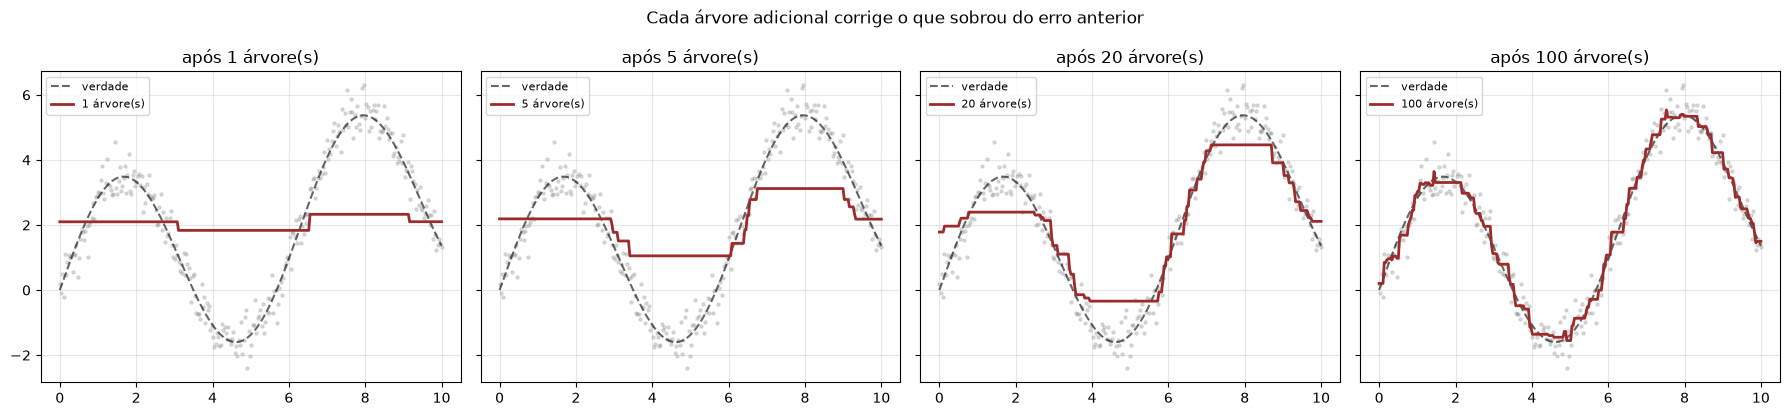

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
for ax, n_arv in zip(axes, [1, 5, 20, 100]):
    pred = modelo_manual.predict(x, n_arvores=n_arv)
    ax.scatter(x, y, s=5, alpha=0.25, color="gray")
    ax.plot(x, y_verdadeiro, color="black", lw=1.5, ls="--", alpha=0.6, label="verdade")
    ax.plot(x, pred, color=VERMELHO, lw=2, label=f"{n_arv} árvore(s)")
    ax.legend(fontsize=8); ax.set_title(f"após {n_arv} árvore(s)")
plt.suptitle("Cada árvore adicional corrige o que sobrou do erro anterior")
plt.tight_layout(); plt.show()

## 3. A curva de perda: caindo a cada árvore adicionada

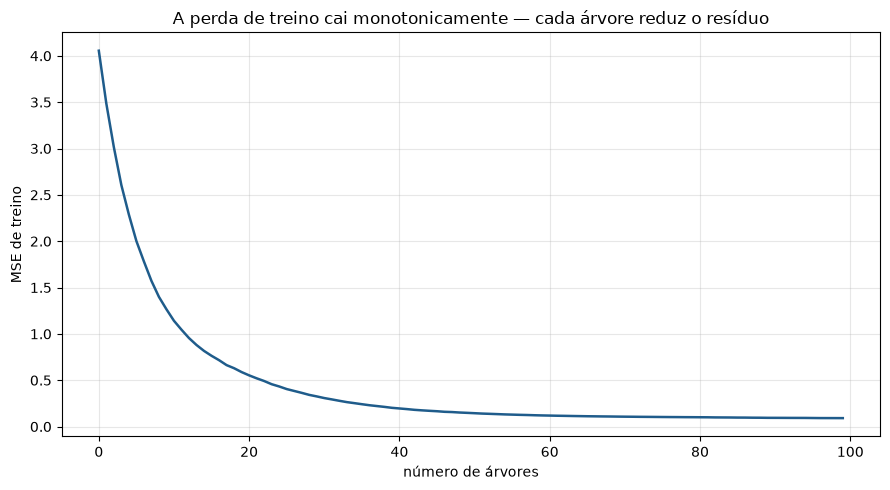

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(modelo_manual.historico_perda_, color=AZUL, lw=1.8)
ax.set_xlabel("número de árvores"); ax.set_ylabel("MSE de treino")
ax.set_title("A perda de treino cai monotonicamente — cada árvore reduz o resíduo")
plt.tight_layout(); plt.show()

## 4. O efeito da taxa de aprendizado

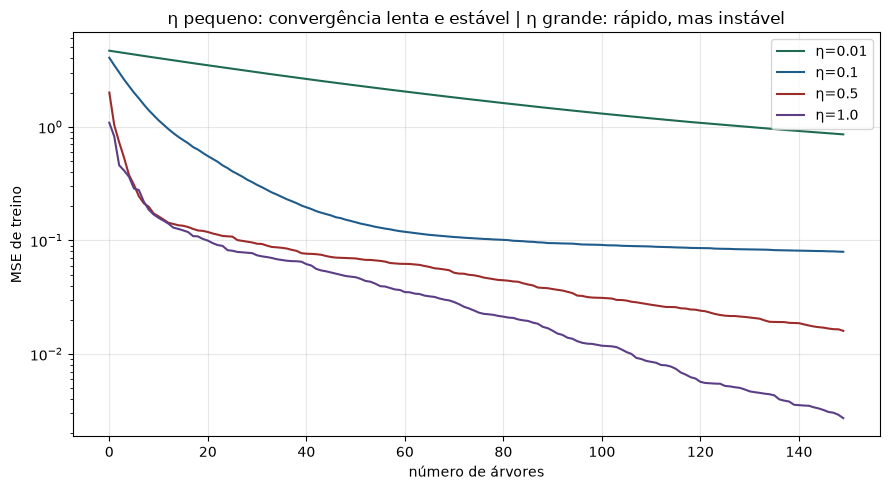

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for eta, cor in [(0.01, VERDE), (0.1, AZUL), (0.5, VERMELHO), (1.0, ROXO)]:
    modelo = GradientBoostingDoZero(
        n_estimadores=150, taxa_aprendizado=eta, profundidade_arvore=2).fit(x, y)
    ax.plot(modelo.historico_perda_, color=cor, lw=1.5, label=f"η={eta}")
ax.set_xlabel("número de árvores"); ax.set_ylabel("MSE de treino")
ax.set_yscale("log")
ax.set_title("η pequeno: convergência lenta e estável | η grande: rápido, mas instável")
ax.legend(); plt.tight_layout(); plt.show()

**Leitura esperada:** $\eta=1{,}0$ pode convergir rápido no início, mas
tende a oscilar ou estabilizar num patamar pior; $\eta=0{,}01$ converge de
forma muito mais suave, mas precisaria de muito mais árvores para chegar
ao mesmo ponto — o trade-off do `teoria.pdf` entre tamanho do passo e
número de passos, agora no espaço de funções.

## O que levar deste notebook

- Para erro quadrático, "ajustar a árvore ao gradiente negativo" é
  literalmente "ajustar a árvore ao resíduo" — a implementação do zero
  torna essa equivalência concreta.
- O ensemble se forma incrementalmente: cada árvore nova ataca
  especificamente o que sobrou do erro das anteriores, visível na
  evolução da previsão árvore por árvore.
- A taxa de aprendizado controla o trade-off entre velocidade de
  convergência e estabilidade — o mesmo princípio de gradiente descendente
  do tema 2, agora no espaço de funções.

→ Próximo: **XGBoost e LightGBM**, os avanços de engenharia que tornam
essa ideia rápida e robusta o suficiente para produção.